In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel(r'D:\Machine_Learning_Project\Netflix_Customer_DATA_FInal.xlsx')

In [3]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,churned
0,a9b75100-82a8-427a-a208-72f24052884a,51.0,other,Basic,NaN,29.0,africa,TV,NaN,Gift Card,1.0,NaN,Action,1
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,NaN,Other,standard,190.00,NaN,EU,mobile,13.99,gift card,NaN,0.03,Sci-Fi,Yes
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27.0,Female,Standard,16.32,10.0,asia,television,13.99,crypto,2.0,NaN,Drama,0
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53.0,other,premium,NaN,12.0,Oceania,Television,NaN,Crypto,NaN,0.35,Horror,1
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56.0,O,Standard,1.89,NaN,Africa,Mobile,13.99,Crypto,2.0,NaN,Action,1


In [4]:
df.describe()

,age,watch_hours,last_login_days,monthly_fee,number_of_profiles,avg_watch_time_per_day
count,4645.000000,4665.000000,4642.000000,4670.000000,4663.000000,4635.000000
mean,44.021744,11.652073,30.610297,14.026195,3.179927,1.031730
std,17.476259,12.281253,22.454330,14.737100,7.849289,6.339571
min,18.000000,0.010000,0.000000,8.990000,1.000000,0.000000
25%,30.000000,3.340000,15.000000,8.990000,2.000000,0.110000
50%,44.000000,7.950000,30.000000,13.990000,3.000000,0.290000
75%,57.000000,15.970000,45.000000,17.990000,4.000000,0.720000
max,459.000000,190.000000,670.000000,780.000000,500.000000,290.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     4645 non-null   float64
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   watch_hours             4665 non-null   float64
 5   last_login_days         4642 non-null   float64
 6   region                  4998 non-null   str    
 7   device                  5000 non-null   str    
 8   monthly_fee             4670 non-null   float64
 9   payment_method          5000 non-null   str    
 10  number_of_profiles      4663 non-null   float64
 11  avg_watch_time_per_day  4635 non-null   float64
 12  favorite_genre          5000 non-null   str    
 13  churned                 5000 non-null   object 
dtypes: float64(6), object(1), str(7)
memory usage: 547.

# Data Preprocessing

In [6]:
for column in df:
    print(column)
    print()
    print(df[column].unique())
    print(df[column].nunique())
    print('--------------------------------')

customer_id

<StringArray>
['a9b75100-82a8-427a-a208-72f24052884a',
 '49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b',
 '4d71f6ce-fca9-4ff7-8afa-197ac24de14b',
 'd3c72c38-631b-4f9e-8a0e-de103cad1a7d',
 '4e265c34-103a-4dbb-9553-76c9aa47e946',
 'd8079475-5be7-47e9-8782-ceb7ff61395e',
 '8e63450a-13d6-4e83-bbb5-6aebde9152cb',
 '02387681-8c42-462a-807a-de0168c73b38',
 '0bcaad0c-545c-4ee1-85a6-75e165f39361',
 'eae6439e-8cdf-4258-ab49-c493925b927a',
 ...
 'edb9036d-95f9-4998-9910-78ba85869dbd',
 'ac6eb271-0239-4957-b828-c89508fcfbea',
 '9721209e-3147-456f-a2c0-81d23b4cf822',
 'f915a366-31c7-4a9e-9042-ca526c771219',
 '75532a22-9cd9-492c-8865-fa4ac7da2ec8',
 '44f3ba44-b95d-4e50-a786-bac4d06f4a43',
 '18779bcb-ba2b-41da-b751-e70b812061ec',
 '3f32e8c5-615b-4a3b-a864-db2688f7834f',
 '7b0ad82d-6571-430e-90f4-906259e0e89c',
 '82aeef39-ddb0-40ad-bae1-5c436e0cf042']
Length: 5000, dtype: str
5000
--------------------------------
age

[ 51.  nan  27.  53.  56.  58.  45.  32.  49.  39.  46.  48.  68.  21.
  70.  55

In [7]:
df.drop('customer_id', axis=1, inplace=True)

In [8]:
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,churned
0,51.0,other,Basic,NaN,29.0,africa,TV,NaN,Gift Card,1.0,NaN,Action,1
1,NaN,Other,standard,190.00,NaN,EU,mobile,13.99,gift card,NaN,0.03,Sci-Fi,Yes
2,27.0,Female,Standard,16.32,10.0,asia,television,13.99,crypto,2.0,NaN,Drama,0
3,53.0,other,premium,NaN,12.0,Oceania,Television,NaN,Crypto,NaN,0.35,Horror,1
4,56.0,O,Standard,1.89,NaN,Africa,Mobile,13.99,Crypto,2.0,NaN,Action,1


In [9]:
print(df['age'].mean())
print(df['age'].median())
print(df['age'].mode())

44.021743810548976
44.0
0    63.0
Name: age, dtype: float64


In [10]:
df['age'] = df['age'].fillna(df['age'].median())

In [11]:
df['age'] = df['age'].astype(int)

In [12]:
# ['other', 'Other', 'Female', 'O', 'F', 'male', 'M', 'female', 'Male']
df['gender'] = df['gender'].replace(['male', 'M'], 'Male')
df['gender'] = df['gender'].replace(['female', 'F'], 'Female')
df['gender'] = df['gender'].replace(['other', 'O'], 'Other')

In [13]:
df['subscription_type'] = df['subscription_type'].str.title()

In [14]:
print(df['watch_hours'].mean())
print(df['watch_hours'].median())
print(df['watch_hours'].mode())

11.652072883172561
7.95
0    0.12
1    0.24
Name: watch_hours, dtype: float64


In [15]:
df['watch_hours'] = df['watch_hours'].fillna(df['watch_hours'].median()) 

In [16]:
print(df['last_login_days'].mean())
print(df['last_login_days'].median())
print(df['last_login_days'].mode())

30.610297285652734
30.0
0    37.0
Name: last_login_days, dtype: float64


In [17]:
df['last_login_days'] = df['last_login_days'].fillna(df['last_login_days'].median())

In [18]:
df['last_login_days'] = df['last_login_days'].astype(int)

In [19]:
# [       'africa',            'EU',          'asia',       'Oceania',
#         'Africa',       'oceania',          'Asia',        'Europe',
#  'south america', 'South America', 'north america', 'North America',
#             'SA',             nan,        'europe']
df['region'] = df['region'].replace(['EU', 'europe'], 'Europe')
df['region'] = df['region'].replace(['SA', 'south america'], 'South America')
df['region'] = df['region'].replace(['NA', 'north america'], 'North America')
df['region'] = df['region'].str.title()

In [20]:
df['region'].mode()

0    South America
Name: region, dtype: str

In [21]:
df['region'] = df['region'].fillna('South America')

In [22]:
# [        'TV',     'mobile', 'television', 'Television',     'Mobile',
#      'laptop',    'desktop',     'tablet',     'Tablet',     'Laptop',
#     'Desktop']
df['device'] = df['device'].replace(['TV', 'television', ], 'Television')
df['device'] = df['device'].str.title()

In [23]:
print(df['monthly_fee'].mean())
print(df['monthly_fee'].median())
print(df['monthly_fee'].mode())

14.026194860813701
13.99
0    17.99
Name: monthly_fee, dtype: float64


In [24]:
df['monthly_fee'] = df['monthly_fee'].fillna(df['monthly_fee'].median())

In [25]:
# [  'Gift Card',   'gift card',      'crypto',      'Crypto',   'debitcard',
#       'paypal',          'DC',  'Debit Card',      'PayPal',          'CC',
#  'Credit Card', 'credit card']
df['payment_method'] = df['payment_method'].replace(['debitcard', 'DC'], 'Debit Card')
df['payment_method'] = df['payment_method'].replace(['credit card', 'CC'], 'Credit Card')
df['payment_method'] = df['payment_method'].replace('paypal', 'PayPal')
df['payment_method'] = df['payment_method'].str.title()

In [26]:
print(df['number_of_profiles'].mean())
print(df['number_of_profiles'].median())
print(df['number_of_profiles'].mode())

3.1799270855672312
3.0
0    5.0
Name: number_of_profiles, dtype: float64


In [27]:
df['number_of_profiles'] = df['number_of_profiles'].fillna(df['number_of_profiles'].median())

In [28]:
df['number_of_profiles'] = df['number_of_profiles'].astype(int)

In [29]:
print(df['avg_watch_time_per_day'].mean())
print(df['avg_watch_time_per_day'].median())
print(df['avg_watch_time_per_day'].mode())

1.0317303128371091
0.29
0    0.01
Name: avg_watch_time_per_day, dtype: float64


In [30]:
df['avg_watch_time_per_day'] = df['avg_watch_time_per_day'].fillna(df['avg_watch_time_per_day'].median())

In [31]:
df.isnull().sum()

age                       0
gender                    0
subscription_type         0
watch_hours               0
last_login_days           0
region                    0
device                    0
monthly_fee               0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
churned                   0
dtype: int64

In [32]:
# [1 'Yes' 0 'no' 'T' 'F' 'No' 'yes']

df['churned'] = df['churned'].replace(['Yes', 'T', 'yes'], 1)
df['churned'] = df['churned'].replace(['No', 'F', 'no'], 0)

In [33]:
df['churned'] = df['churned'].astype(int)

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5000 non-null   int64  
 1   gender                  5000 non-null   str    
 2   subscription_type       5000 non-null   str    
 3   watch_hours             5000 non-null   float64
 4   last_login_days         5000 non-null   int64  
 5   region                  5000 non-null   str    
 6   device                  5000 non-null   str    
 7   monthly_fee             5000 non-null   float64
 8   payment_method          5000 non-null   str    
 9   number_of_profiles      5000 non-null   int64  
 10  avg_watch_time_per_day  5000 non-null   float64
 11  favorite_genre          5000 non-null   str    
 12  churned                 5000 non-null   int64  
dtypes: float64(3), int64(4), str(6)
memory usage: 507.9 KB


In [35]:
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,churned
0,51,Other,Basic,7.95,29,Africa,Television,13.99,Gift Card,1,0.29,Action,1
1,44,Other,Standard,190.00,30,Europe,Mobile,13.99,Gift Card,3,0.03,Sci-Fi,1
2,27,Female,Standard,16.32,10,Asia,Television,13.99,Crypto,2,0.29,Drama,0
3,53,Other,Premium,7.95,12,Oceania,Television,13.99,Crypto,3,0.35,Horror,1
4,56,Other,Standard,1.89,30,Africa,Mobile,13.99,Crypto,2,0.29,Action,1


In [36]:
df.tail()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,churned
4995,19,Female,Basic,49.17,11,Europe,Desktop,8.99,Credit Card,4,4.10,Drama,0
4996,67,Female,Basic,9.24,2,South America,Desktop,8.99,Paypal,3,3.08,Documentary,0
4997,66,Male,Standard,16.55,49,South America,Desktop,13.99,Debit Card,2,0.33,Action,1
4998,59,Female,Basic,9.12,3,Europe,Laptop,8.99,Credit Card,4,2.28,Sci-Fi,0
4999,57,Male,Basic,1.62,17,Africa,Mobile,8.99,Crypto,2,0.09,Action,1


# Data Analysis & Visualization

> What is the overall percentage of churned vs. retained users in the dataset?

In [37]:
df['churned'].value_counts()

churned
1    2516
0    2484
Name: count, dtype: int64

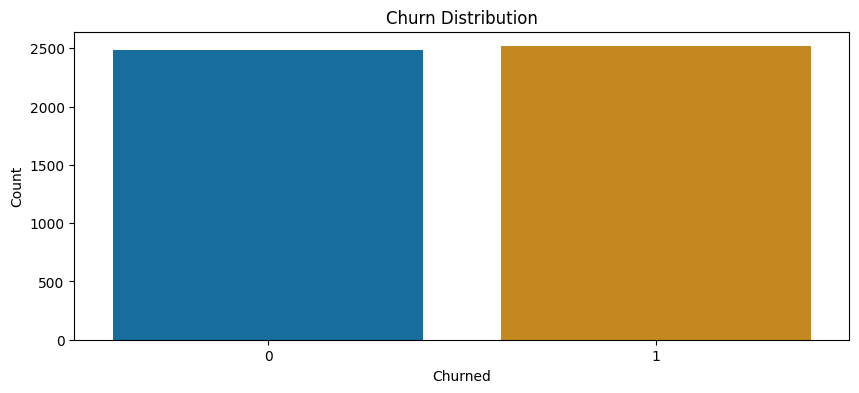

In [38]:
plt.figure(figsize=(10, 4))
sns.countplot(x = 'churned', data = df, palette='colorblind')
plt.title('Churn Distribution')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.show()

> Is there a specific gender that is more likely to cancel their subscription?

In [39]:
df.groupby('gender')['churned'].mean()

gender
Female    0.510812
Male      0.500000
Other     0.498471
Name: churned, dtype: float64

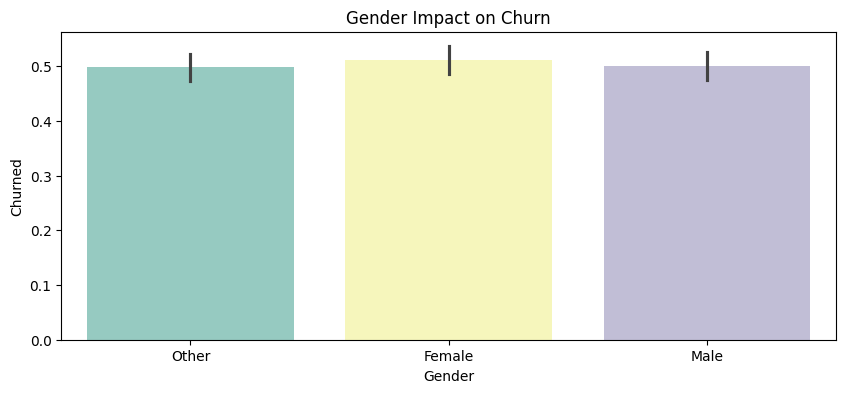

In [40]:
plt.figure(figsize=(10, 4))
sns.barplot(x = 'gender', y = 'churned', data=df, palette='Set3')
plt.title('Gender Impact on Churn')
plt.xlabel("Gender")
plt.ylabel('Churned')
plt.show()

> Which age group has the highest total watch_hours?

In [41]:
df['age'].nlargest()

309    459
337    370
276    190
245    120
21      70
Name: age, dtype: int64

In [42]:
df['age'].unique()

array([ 51,  44,  27,  53,  56,  58,  45,  32,  49,  39,  46,  48,  68,
        21,  70,  55,  24,  69,  47,  67,  23,  22,  34,  19,  36,  31,
        42,  63,  66,  65,  64,  62,  35,  41,  60,  18,  26,  37,  50,
        20,  61,  59,  30,  29,  40,  54,  33,  28,  57,  52,  38, 120,
       190, 459, 370,  43,  25])

In [43]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)

In [44]:
df.groupby('age_group')['watch_hours'].sum()

age_group
<18       1008.23
18-25     7068.68
26-35     9500.32
36-45    13630.56
46-55     9467.15
56-65    10828.90
65+       5399.90
Name: watch_hours, dtype: float64

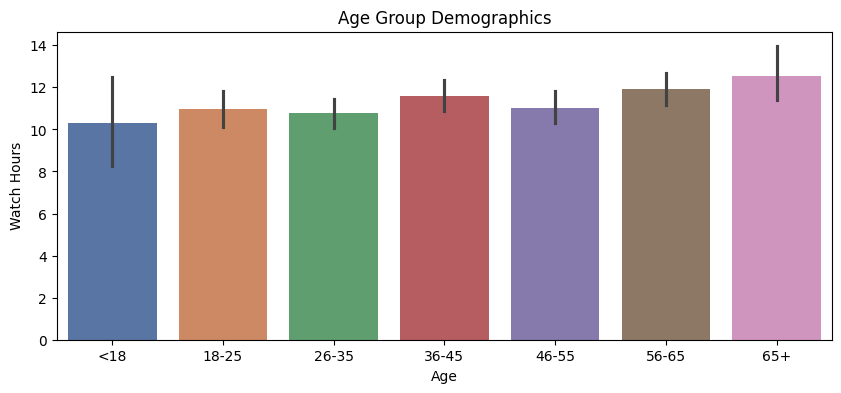

In [45]:
plt.figure(figsize=(10, 4))
sns.barplot(x='age_group', y='watch_hours', data=df, palette='deep')
plt.title('Age Group Demographics')
plt.xlabel('Age')
plt.ylabel('Watch Hours')
plt.show()

> Which subscription_type contributes the most to the total revenue based on monthly_fee?

In [46]:
df.groupby('subscription_type')['monthly_fee'].sum()

subscription_type
Basic       15472.39
Premium     30853.09
Standard    23793.55
Name: monthly_fee, dtype: float64

In [47]:
df['subscription_type'].value_counts()

subscription_type
Premium     1693
Basic       1661
Standard    1646
Name: count, dtype: int64

In [48]:
df.groupby('subscription_type')['churned'].mean()

subscription_type
Basic       0.618302
Premium     0.437094
Standard    0.455043
Name: churned, dtype: float64

In [49]:
df.groupby('subscription_type')['monthly_fee'].mean()

subscription_type
Basic        9.315105
Premium     18.223916
Standard    14.455377
Name: monthly_fee, dtype: float64

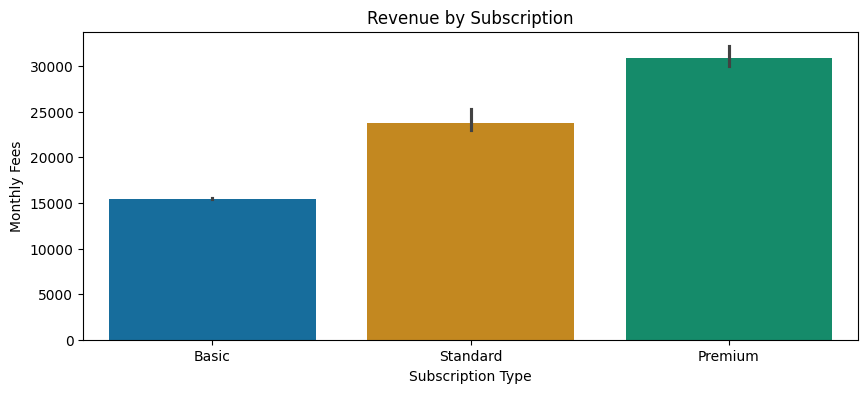

In [50]:
plt.figure(figsize=(10, 4))
sns.barplot(x='subscription_type', y='monthly_fee', data=df, palette='colorblind', estimator=sum)
plt.title('Revenue by Subscription')
plt.xlabel('Subscription Type')
plt.ylabel('Monthly Fees')
plt.show()

> What is the most preferred favorite_genre in different geographical regions?

In [51]:
df.head(1)

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,churned,age_group
0,51,Other,Basic,7.95,29,Africa,Television,13.99,Gift Card,1,0.29,Action,1,46-55


In [52]:
pivot = df.pivot_table(
    index = 'region',
    columns='favorite_genre',
    values = 'watch_hours',
    aggfunc='sum'
)

In [53]:
pivot

favorite_genre,Action,Comedy,Documentary,Drama,Horror,Romance,Sci-Fi
region,,,,,,,
Africa,1095.04,1456.81,1700.76,1205.71,1307.75,1339.24,1094.49
Asia,1099.56,1458.27,1384.73,1241.75,1310.54,1528.24,1244.08
Europe,1467.82,1116.58,1179.81,1395.35,1286.26,1544.86,1749.87
North America,1216.71,1456.14,1336.05,1522.55,1398.70,1504.25,1450.14
Oceania,1288.47,1101.46,1173.66,1370.97,1217.71,1427.32,1151.10
South America,1370.42,1436.48,1378.25,1554.44,1120.15,1808.53,1529.15


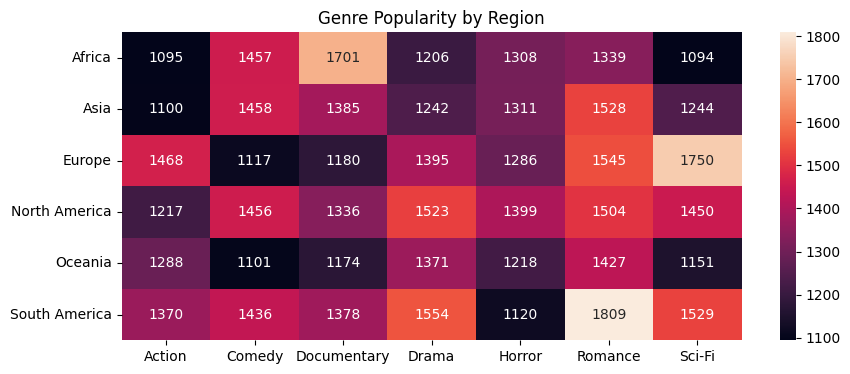

In [54]:
plt.figure(figsize=(10, 4))
sns.heatmap(pivot, cmap="rocket", annot=True, fmt=".0f")
plt.title('Genre Popularity by Region')
plt.xlabel(None)
plt.ylabel(None)
plt.show()

> Do users with lower avg_watch_time_per_day have a higher tendency to churn?

In [55]:
df.groupby('churned')['avg_watch_time_per_day'].mean()

churned
0    1.572786
1    0.389952
Name: avg_watch_time_per_day, dtype: float64

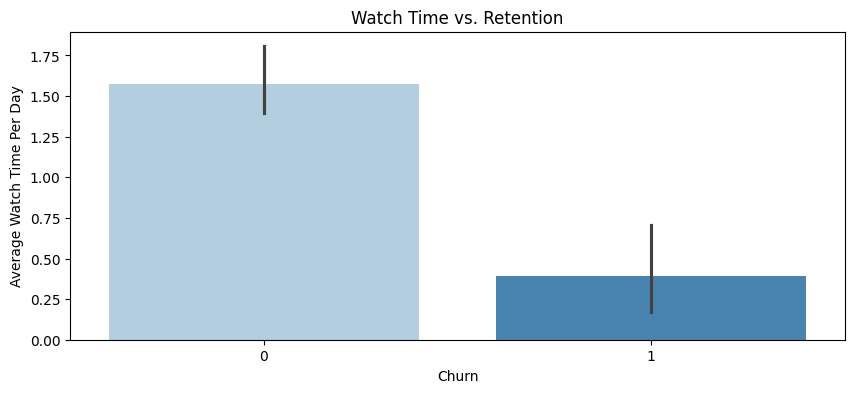

In [56]:
plt.figure(figsize=(10, 4))
sns.barplot(x = 'churned', y = 'avg_watch_time_per_day', data=df, palette='Blues')
plt.title('Watch Time vs. Retention')
plt.xlabel('Churn')
plt.ylabel('Average Watch Time Per Day')
plt.show()

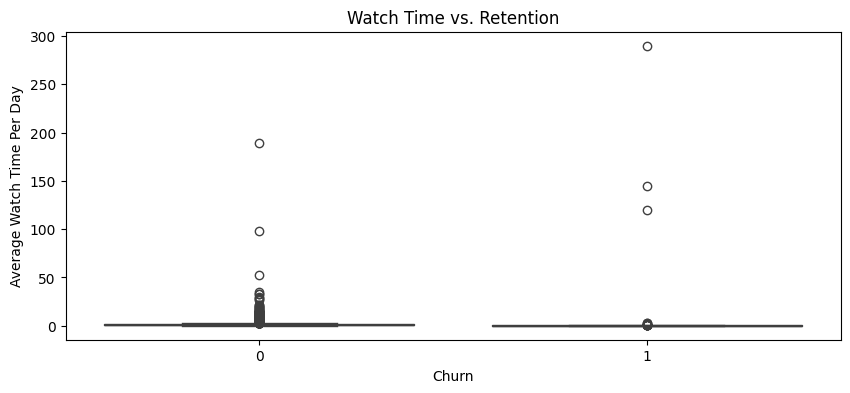

In [57]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='churned', y='avg_watch_time_per_day', data=df)
plt.title('Watch Time vs. Retention')
plt.xlabel('Churn')
plt.ylabel('Average Watch Time Per Day')
plt.show()

> Which device is most commonly used by long-term subscribers, and does it impact the churn rate?

In [58]:
df.groupby('device')['churned'].mean()

device
Desktop       0.492097
Laptop        0.517893
Mobile        0.505976
Tablet        0.500000
Television    0.499496
Name: churned, dtype: float64

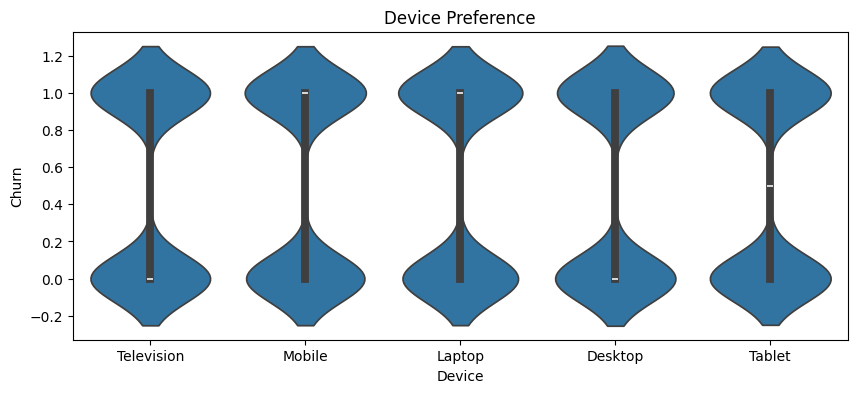

In [59]:
plt.figure(figsize=(10, 4))
sns.violinplot(x='device', y='churned', data=df)
plt.title('Device Preference')
plt.xlabel("Device")
plt.ylabel("Churn")
plt.show()

> What is the correlation between last_login_days and churned status? At what point is a user considered "inactive"?

In [60]:
df['last_login_days'].corr(df['churned'])

np.float64(0.34260892608907983)

In [61]:
df.groupby('churned')['last_login_days'].mean()

churned
0    23.107085
1    37.931240
Name: last_login_days, dtype: float64

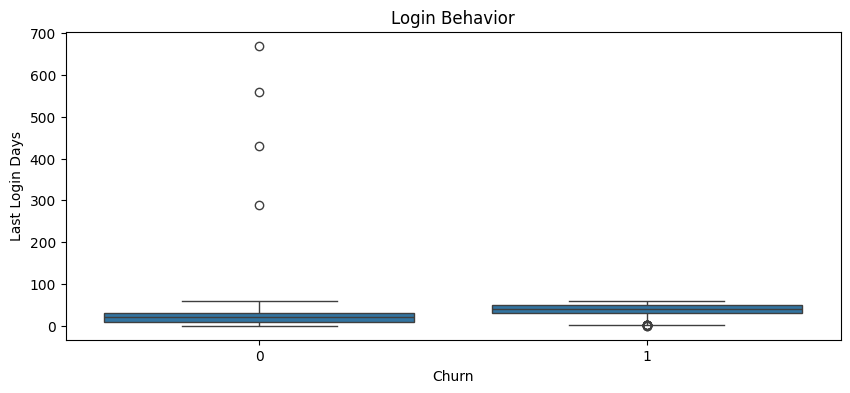

In [62]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='churned', y='last_login_days', data=df)
plt.title('Login Behavior')
plt.xlabel('Churn')
plt.ylabel('Last Login Days')
plt.show()

> Does the monthly_fee vary significantly across different regions for the same subscription type?

In [63]:
df.head(1)

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,churned,age_group
0,51,Other,Basic,7.95,29,Africa,Television,13.99,Gift Card,1,0.29,Action,1,46-55


In [64]:
df.groupby(['subscription_type', 'region'])['monthly_fee'].mean()

subscription_type  region       
Basic              Africa            9.259231
                   Asia              9.253158
                   Europe            9.359718
                   North America     9.387924
                   Oceania           9.299917
                   South America     9.322226
Premium            Africa           17.750300
                   Asia             17.814818
                   Europe           19.221869
                   North America    17.753066
                   Oceania          17.638352
                   South America    19.032937
Standard           Africa           16.765399
                   Asia             13.990000
                   Europe           13.990000
                   North America    13.990000
                   Oceania          13.990000
                   South America    13.990000
Name: monthly_fee, dtype: float64

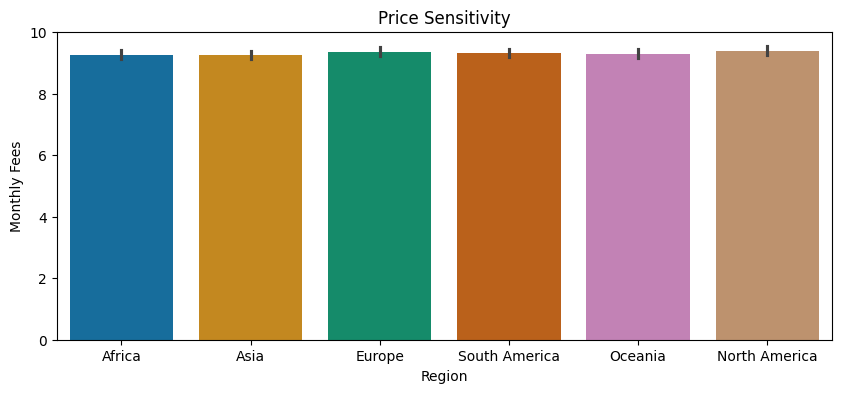

In [65]:
plt.figure(figsize=(10, 4))
sns.barplot(x='region', y='monthly_fee', data=df[df['subscription_type'] == 'Basic'], palette='colorblind')
plt.title('Price Sensitivity')
plt.xlabel('Region')
plt.ylabel('Monthly Fees')
plt.show()

> Does having a higher number_of_profiles lead to increased total watch_hours?

In [66]:
df.groupby('number_of_profiles')['watch_hours'].sum()

number_of_profiles
1      10180.62
2       9971.04
3      14410.84
4      11626.83
5      10810.70
100        4.39
150        5.61
500       10.14
Name: watch_hours, dtype: float64

In [67]:
df.groupby('number_of_profiles')['watch_hours'].mean()

number_of_profiles
1      11.150734
2      10.721548
3      11.437175
4      12.448426
5      11.261146
100     4.390000
150     5.610000
500    10.140000
Name: watch_hours, dtype: float64

In [68]:
df_filtered = df[df['number_of_profiles'] < 10]

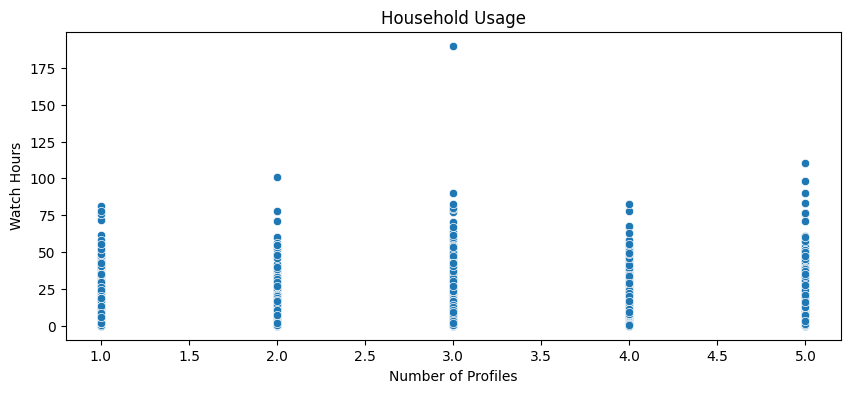

In [69]:
plt.figure(figsize=(10, 4))
sns.scatterplot(x = 'number_of_profiles', y = 'watch_hours', data=df_filtered)
plt.title('Household Usage')
plt.xlabel('Number of Profiles')
plt.ylabel('Watch Hours')
plt.show()

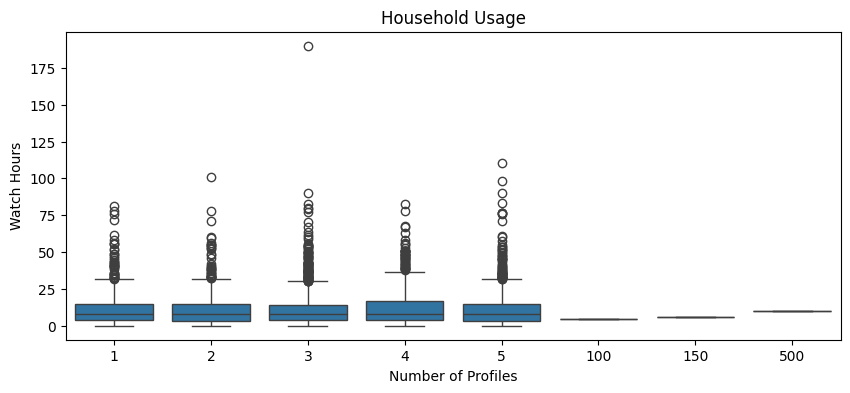

In [70]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='number_of_profiles', y='watch_hours', data=df)
plt.title('Household Usage')
plt.xlabel('Number of Profiles')
plt.ylabel('Watch Hours')
plt.show()

> Is there a specific payment_method associated with a higher churn rate (potentially due to transaction failures)? 

In [71]:
df.groupby('payment_method')['churned'].mean()

payment_method
Credit Card    0.436793
Crypto         0.596985
Debit Card     0.436893
Gift Card      0.577869
Paypal         0.470760
Name: churned, dtype: float64

In [72]:
df.groupby('payment_method').agg({
    'churned': 'mean',
    'payment_method': 'count'
})

,churned,payment_method
payment_method,,
Credit Card,0.436793,973
Crypto,0.596985,995
Debit Card,0.436893,1030
Gift Card,0.577869,976
Paypal,0.470760,1026


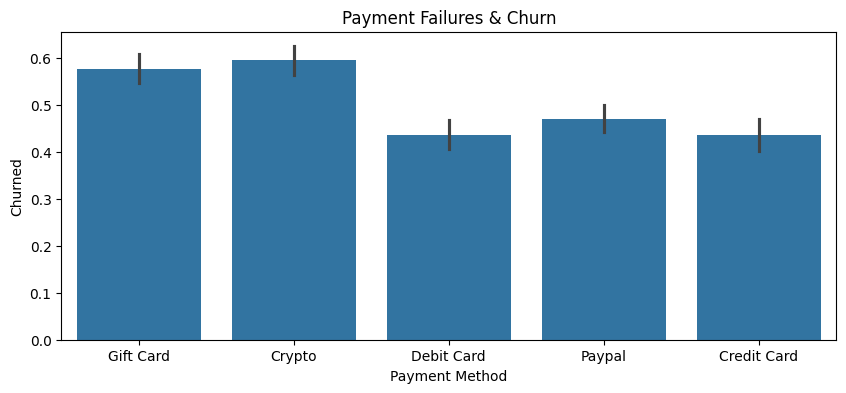

In [73]:
plt.figure(figsize=(10, 4))
sns.barplot(x='payment_method', y='churned', data=df)
plt.title('Payment Failures & Churn')
plt.xlabel('Payment Method')
plt.ylabel('Churned')
plt.show()

> How do numerical features like age, watch_hours, and monthly_fee relate to each other? (Seaborn Heatmap)

In [74]:
num_df = df.select_dtypes(include=['int64', 'float64'])

In [75]:
corr_matrix = num_df.corr()

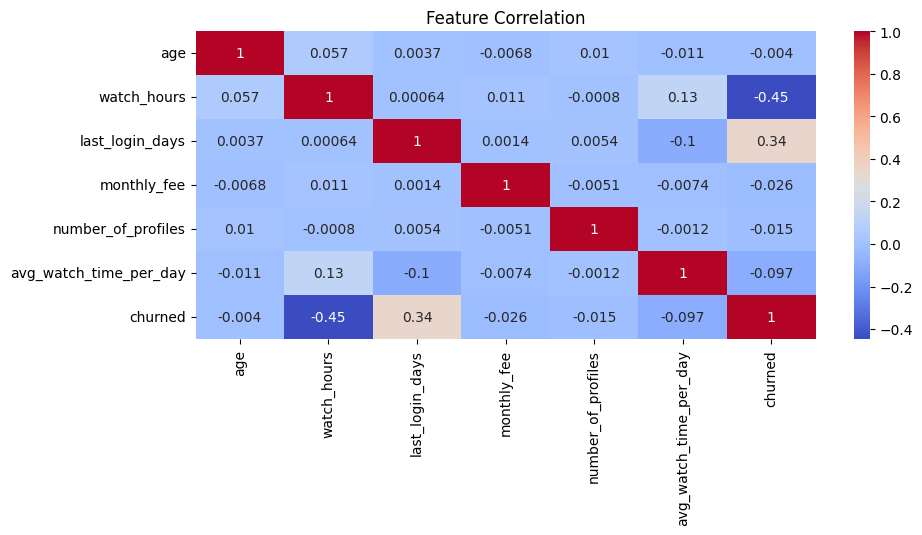

In [76]:
plt.figure(figsize=(10, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [77]:
corr_matrix['churned'].sort_values(ascending=False)

churned                   1.000000
last_login_days           0.342609
age                      -0.004010
number_of_profiles       -0.015103
monthly_fee              -0.025899
avg_watch_time_per_day   -0.096853
watch_hours              -0.448639
Name: churned, dtype: float64

# Model Building

In [78]:
df.head(3)

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,churned,age_group
0,51,Other,Basic,7.95,29,Africa,Television,13.99,Gift Card,1,0.29,Action,1,46-55
1,44,Other,Standard,190.00,30,Europe,Mobile,13.99,Gift Card,3,0.03,Sci-Fi,1,36-45
2,27,Female,Standard,16.32,10,Asia,Television,13.99,Crypto,2,0.29,Drama,0,26-35


In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   age                     5000 non-null   int64   
 1   gender                  5000 non-null   str     
 2   subscription_type       5000 non-null   str     
 3   watch_hours             5000 non-null   float64 
 4   last_login_days         5000 non-null   int64   
 5   region                  5000 non-null   str     
 6   device                  5000 non-null   str     
 7   monthly_fee             5000 non-null   float64 
 8   payment_method          5000 non-null   str     
 9   number_of_profiles      5000 non-null   int64   
 10  avg_watch_time_per_day  5000 non-null   float64 
 11  favorite_genre          5000 non-null   str     
 12  churned                 5000 non-null   int64   
 13  age_group               4996 non-null   category
dtypes: category(1), float64(3), int64(4

In [80]:
df.columns

Index(['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days',
       'region', 'device', 'monthly_fee', 'payment_method',
       'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre',
       'churned', 'age_group'],
      dtype='str')

In [81]:
df.drop('age_group', axis = 1, inplace=True)

In [82]:
features = df.drop('churned', axis=1)
target = df['churned']

In [83]:
features

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,7.95,29,Africa,Television,13.99,Gift Card,1,0.29,Action
1,44,Other,Standard,190.00,30,Europe,Mobile,13.99,Gift Card,3,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,Television,13.99,Crypto,2,0.29,Drama
3,53,Other,Premium,7.95,12,Oceania,Television,13.99,Crypto,3,0.35,Horror
4,56,Other,Standard,1.89,30,Africa,Mobile,13.99,Crypto,2,0.29,Action
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,19,Female,Basic,49.17,11,Europe,Desktop,8.99,Credit Card,4,4.10,Drama
4996,67,Female,Basic,9.24,2,South America,Desktop,8.99,Paypal,3,3.08,Documentary
4997,66,Male,Standard,16.55,49,South America,Desktop,13.99,Debit Card,2,0.33,Action
4998,59,Female,Basic,9.12,3,Europe,Laptop,8.99,Credit Card,4,2.28,Sci-Fi


In [84]:
target

0       1
1       1
2       0
3       1
4       1
       ..
4995    0
4996    0
4997    1
4998    0
4999    1
Name: churned, Length: 5000, dtype: int64

In [85]:
df.columns

Index(['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days',
       'region', 'device', 'monthly_fee', 'payment_method',
       'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre',
       'churned'],
      dtype='str')

In [86]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

order = ['Basic', 'Standard', 'Premium']

ordinal_cols = ['subscription_type']
ohe_cols = ['gender', 'region', 'device', 'payment_method', 'favorite_genre']

transformer = ColumnTransformer(transformers=[
    ('ord', OrdinalEncoder(categories=[order]), ordinal_cols),
    ('ohe', OneHotEncoder(sparse_output=False, drop='first'), ohe_cols)
], remainder='passthrough')

features_transformed = transformer.fit_transform(features)

encoded_cols = transformer.get_feature_names_out()
features_final = pd.DataFrame(features_transformed, columns=encoded_cols)

In [87]:
features_final.head()

,ord__subscription_type,ohe__gender_Male,ohe__gender_Other,ohe__region_Asia,ohe__region_Europe,ohe__region_North America,ohe__region_Oceania,ohe__region_South America,ohe__device_Laptop,ohe__device_Mobile,...,ohe__favorite_genre_Drama,ohe__favorite_genre_Horror,ohe__favorite_genre_Romance,ohe__favorite_genre_Sci-Fi,remainder__age,remainder__watch_hours,remainder__last_login_days,remainder__monthly_fee,remainder__number_of_profiles,remainder__avg_watch_time_per_day
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,51.0,7.95,29.0,13.99,1.0,0.29
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,44.0,190.00,30.0,13.99,3.0,0.03
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,27.0,16.32,10.0,13.99,2.0,0.29
3,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,53.0,7.95,12.0,13.99,3.0,0.35
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,56.0,1.89,30.0,13.99,2.0,0.29


In [88]:
features_final.columns

Index(['ord__subscription_type', 'ohe__gender_Male', 'ohe__gender_Other',
       'ohe__region_Asia', 'ohe__region_Europe', 'ohe__region_North America',
       'ohe__region_Oceania', 'ohe__region_South America',
       'ohe__device_Laptop', 'ohe__device_Mobile', 'ohe__device_Tablet',
       'ohe__device_Television', 'ohe__payment_method_Crypto',
       'ohe__payment_method_Debit Card', 'ohe__payment_method_Gift Card',
       'ohe__payment_method_Paypal', 'ohe__favorite_genre_Comedy',
       'ohe__favorite_genre_Documentary', 'ohe__favorite_genre_Drama',
       'ohe__favorite_genre_Horror', 'ohe__favorite_genre_Romance',
       'ohe__favorite_genre_Sci-Fi', 'remainder__age',
       'remainder__watch_hours', 'remainder__last_login_days',
       'remainder__monthly_fee', 'remainder__number_of_profiles',
       'remainder__avg_watch_time_per_day'],
      dtype='str')

In [89]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(features_final, target, test_size=0.20, random_state=42)

In [90]:
xtrain

,ord__subscription_type,ohe__gender_Male,ohe__gender_Other,ohe__region_Asia,ohe__region_Europe,ohe__region_North America,ohe__region_Oceania,ohe__region_South America,ohe__device_Laptop,ohe__device_Mobile,...,ohe__favorite_genre_Drama,ohe__favorite_genre_Horror,ohe__favorite_genre_Romance,ohe__favorite_genre_Sci-Fi,remainder__age,remainder__watch_hours,remainder__last_login_days,remainder__monthly_fee,remainder__number_of_profiles,remainder__avg_watch_time_per_day
4227,2.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,54.0,9.80,56.0,17.99,4.0,0.17
4676,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,31.0,10.38,42.0,8.99,1.0,0.24
800,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,59.0,20.13,6.0,8.99,1.0,2.88
3671,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,45.0,9.77,16.0,8.99,2.0,0.57
4193,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,36.0,9.10,2.0,13.99,2.0,3.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,41.0,1.20,49.0,13.99,4.0,0.02
466,2.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,32.0,24.87,30.0,13.99,3.0,0.29
3092,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,18.0,3.54,45.0,13.99,5.0,0.08
3772,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,50.0,7.96,51.0,17.99,5.0,0.15


In [91]:
xtest

,ord__subscription_type,ohe__gender_Male,ohe__gender_Other,ohe__region_Asia,ohe__region_Europe,ohe__region_North America,ohe__region_Oceania,ohe__region_South America,ohe__device_Laptop,ohe__device_Mobile,...,ohe__favorite_genre_Drama,ohe__favorite_genre_Horror,ohe__favorite_genre_Romance,ohe__favorite_genre_Sci-Fi,remainder__age,remainder__watch_hours,remainder__last_login_days,remainder__monthly_fee,remainder__number_of_profiles,remainder__avg_watch_time_per_day
1501,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,39.0,9.96,22.0,8.99,5.0,0.43
2586,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,18.0,0.25,37.0,13.99,5.0,0.01
2653,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,19.0,8.54,6.0,13.99,3.0,1.22
1055,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,34.0,13.49,51.0,17.99,1.0,0.26
705,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,29.0,24.18,59.0,8.99,1.0,0.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4711,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,18.0,12.22,48.0,17.99,5.0,0.25
2313,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,0.0,0.0,33.0,1.32,36.0,13.99,1.0,0.04
3214,2.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,42.0,9.19,5.0,17.99,5.0,1.53
2732,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,22.0,29.96,43.0,8.99,5.0,0.68


In [92]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

xtrain_scaled = sc.fit_transform(xtrain)
xtest_scaled = sc.transform(xtest)

In [93]:
xtrain_scaled

array([[ 1.21209315, -0.69824196,  1.42811543, ...,  0.40185947,
         0.46939557, -0.15803517],
       [-1.21999744, -0.69824196,  1.42811543, ..., -0.48183478,
        -0.99137902, -0.14391552],
       [-1.21999744, -0.69824196,  1.42811543, ..., -0.48183478,
        -0.99137902,  0.38859691],
       ...,
       [-0.00395215, -0.69824196,  1.42811543, ...,  0.00910647,
         0.95632043, -0.176189  ],
       [ 1.21209315,  1.4321683 , -0.70022351, ...,  0.40185947,
         0.95632043, -0.16206935],
       [ 1.21209315,  1.4321683 , -0.70022351, ...,  0.40185947,
         0.46939557,  0.07393048]], shape=(4000, 28))

In [94]:
xtest_scaled

array([[-1.21999744, -0.69824196,  1.42811543, ..., -0.48183478,
         0.95632043, -0.10559076],
       [-0.00395215, -0.69824196, -0.70022351, ...,  0.00910647,
         0.95632043, -0.19030865],
       [-0.00395215, -0.69824196, -0.70022351, ...,  0.00910647,
        -0.0175293 ,  0.05375955],
       ...,
       [ 1.21209315, -0.69824196,  1.42811543, ...,  0.40185947,
         0.95632043,  0.11628942],
       [-1.21999744, -0.69824196,  1.42811543, ..., -0.48183478,
         0.95632043, -0.05516345],
       [-1.21999744, -0.69824196,  1.42811543, ..., -0.48183478,
        -0.0175293 , -0.09147111]], shape=(1000, 28))

In [95]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr = LogisticRegression()
lr.fit(xtrain_scaled, ytrain)
ypred = lr.predict(xtest_scaled)

accuracy_score(ytest, ypred)

0.868

In [96]:
from sklearn.metrics import classification_report
print(classification_report(ytest, ypred))

              precision    recall  f1-score   support

           0       0.87      0.86      0.87       498
           1       0.86      0.88      0.87       502

    accuracy                           0.87      1000
   macro avg       0.87      0.87      0.87      1000
weighted avg       0.87      0.87      0.87      1000



In [97]:
print(lr.score(xtrain_scaled, ytrain))
print(lr.score(xtest_scaled, ytest))

0.85925
0.868


In [98]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(xtrain_scaled, ytrain)
ypred = dt.predict(xtest_scaled)

In [99]:
from sklearn.metrics import accuracy_score
print(accuracy_score(ytest, ypred))
print()
print(dt.score(xtrain_scaled, ytrain))
print(dt.score(xtest_scaled, ytest))

0.946

1.0
0.946


In [100]:
from sklearn.tree import DecisionTreeClassifier
for i in range(1, 31):
    dt1 = DecisionTreeClassifier(max_depth=i)
    dt1.fit(xtrain_scaled, ytrain)
    ypred = dt1.predict(xtest_scaled)
    ac = accuracy_score(ytest, ypred)
    print(f"{i}: {ac}")

# i = 18

1: 0.805
2: 0.805
3: 0.861
4: 0.883
5: 0.893
6: 0.922
7: 0.945
8: 0.952
9: 0.938
10: 0.945
11: 0.944
12: 0.951
13: 0.946
14: 0.945
15: 0.947
16: 0.943
17: 0.938
18: 0.94
19: 0.944
20: 0.942
21: 0.945
22: 0.941
23: 0.946
24: 0.946
25: 0.947
26: 0.94
27: 0.942
28: 0.941
29: 0.943
30: 0.944


In [101]:
for i in range(2, 75):
    dt2 = DecisionTreeClassifier(min_samples_split=i)
    dt2.fit(xtrain_scaled, ytrain)
    ypred = dt2.predict(xtest_scaled)
    ac = accuracy_score(ytest, ypred)
    print(f"{i}: {ac}")

# i = 13

2: 0.942
3: 0.944
4: 0.947
5: 0.939
6: 0.943
7: 0.946
8: 0.947
9: 0.947
10: 0.947
11: 0.95
12: 0.95
13: 0.95
14: 0.949
15: 0.949
16: 0.948
17: 0.949
18: 0.948
19: 0.948
20: 0.948
21: 0.948
22: 0.948
23: 0.949
24: 0.948
25: 0.95
26: 0.95
27: 0.948
28: 0.948
29: 0.948
30: 0.946
31: 0.946
32: 0.946
33: 0.946
34: 0.946
35: 0.944
36: 0.944
37: 0.945
38: 0.945
39: 0.944
40: 0.944
41: 0.944
42: 0.942
43: 0.941
44: 0.941
45: 0.941
46: 0.941
47: 0.941
48: 0.941
49: 0.941
50: 0.941
51: 0.941
52: 0.941
53: 0.94
54: 0.94
55: 0.94
56: 0.936
57: 0.934
58: 0.934
59: 0.934
60: 0.934
61: 0.934
62: 0.934
63: 0.933
64: 0.933
65: 0.933
66: 0.933
67: 0.933
68: 0.932
69: 0.932
70: 0.932
71: 0.932
72: 0.932
73: 0.932
74: 0.932


In [102]:
for i in range(1, 50):
    dt3 = DecisionTreeClassifier(min_samples_leaf=i)
    dt3.fit(xtrain_scaled, ytrain)
    ypred = dt3.predict(xtest_scaled)
    ac = accuracy_score(ytest, ypred)
    print(f"{i}: {ac}")

# i = 7

1: 0.944
2: 0.942
3: 0.943
4: 0.94
5: 0.946
6: 0.943
7: 0.948
8: 0.948
9: 0.946
10: 0.944
11: 0.943
12: 0.943
13: 0.942
14: 0.939
15: 0.939
16: 0.933
17: 0.931
18: 0.932
19: 0.932
20: 0.93
21: 0.93
22: 0.93
23: 0.923
24: 0.927
25: 0.927
26: 0.923
27: 0.923
28: 0.923
29: 0.922
30: 0.909
31: 0.909
32: 0.909
33: 0.909
34: 0.909
35: 0.915
36: 0.915
37: 0.914
38: 0.903
39: 0.898
40: 0.898
41: 0.894
42: 0.897
43: 0.897
44: 0.897
45: 0.896
46: 0.896
47: 0.897
48: 0.897
49: 0.897


In [103]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier(max_depth=18, min_samples_split=13, min_samples_leaf=7)
DT.fit(xtrain_scaled, ytrain)
ypredict = DT.predict(xtest_scaled)

In [104]:
from sklearn.metrics import accuracy_score
print(accuracy_score(ytest, ypredict))
print()
print(DT.score(xtrain_scaled, ytrain))
print(DT.score(xtest_scaled, ytest))

0.948

0.96725
0.948


In [105]:
print(classification_report(ytest, ypredict))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       498
           1       0.95      0.95      0.95       502

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



In [106]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(DT, xtrain_scaled, ytrain, cv=5)
print("Mean Accuracy: ", scores.mean())

Mean Accuracy:  0.9372499999999999
